In [106]:
from gym_sepsis.envs.sepsis_env_modified import SepsisEnv
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import os
import datetime

# -------------------------
# Device setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 8289
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)



Using device: cpu


In [107]:
# -------------------------
# Environment setup
# -------------------------
env = SepsisEnv()

env.seed(SEED)
env.action_space.seed(SEED)

reset_output = env.reset()
if isinstance(reset_output, tuple):
    state = reset_output[0]
else:
    state = reset_output
state = np.array(state).flatten()

state_size = len(state)
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)


State size: 46
Action size: 24


In [108]:
# obs = env.reset()
# done = False
# while not done:
#     action = env.action_space.sample()
#     obs, reward, done, info = env.step(0)
#     print(reward)

In [109]:
# -------------------------
# Q-network (shared by online and target)
# -------------------------
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, layers=3, hidden=128):
        super(QNetwork, self).__init__()
        self.fc_in = nn.Linear(state_size, hidden)
        self.fc = nn.ModuleList()
        for _ in range(layers):
            self.fc.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, action_size)

    def forward(self, x):
        x = torch.relu(self.fc_in(x))
        for layer in self.fc:
            x = torch.relu(layer(x))
        return self.fc_out(x)


In [110]:
# -------------------------
# Hyperparameters
# -------------------------
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.005
epsilon_decay = 0.99
lr = 5e-4
batch_size = 128
memory_size = 20000
num_episodes = 1000
target_update_freq = 5
eval_episodes = 200  # for evaluation

time_stamp = datetime.datetime.now().timestamp().__round__()
unique_id = str(time_stamp)
save_path = f"policies/policy_net_{unique_id}.pth"


In [111]:
# -------------------------
# Initialize networks, optimizer, memory
# -------------------------
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr, eps=1e-4)
torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
loss_fn = nn.HuberLoss()
memory = deque(maxlen=memory_size)


In [112]:
# -------------------------
# Helper functions
# -------------------------
def get_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return torch.argmax(q_values).item()

def replay():
    if len(memory) < batch_size:
        return None
    
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Q-learning (Double DQN)
    q_values = policy_net(states).gather(1, actions)
    next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
    next_q_values = target_net(next_states).gather(1, next_actions).detach()
    target_q = rewards + (gamma * next_q_values * (1 - dones))

    loss = loss_fn(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [113]:
# -------------------------
# Training loop
# -------------------------
reward_history, loss_history, episode_length = [], [], []
epsilon_history, action_counts = [], np.zeros(action_size, dtype=int)

for episode in range(num_episodes):
    reset_output = env.reset()
    state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
    state = np.array(state).flatten()
    done, total_reward, steps = False, 0, 0
    episode_losses = []

    while not done:
        action = get_action(state, epsilon)
        step_output = env.step(action)
        if len(step_output) == 5:
            next_state, reward, terminated, truncated, info = step_output
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_output
        next_state = np.array(next_state).flatten()

        memory.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        steps += 1
        action_counts[action] += 1

        loss_val = replay()
        if loss_val is not None:
            episode_losses.append(loss_val)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)
    epsilon_history.append(epsilon)
    episode_length.append(steps)
    loss_history.append(np.mean(episode_losses) if episode_losses else 0)

    print("Episode {}/{} | Reward: {:.2f} | Steps: {} | Eps: {:.3f}".format(
        episode+1, num_episodes, total_reward, steps, epsilon))

# Save trained policy
torch.save(policy_net.state_dict(), save_path)
print("Saved trained policy to '{}'".format(save_path))


Episode 1/1000 | Reward: 4.27 | Steps: 10 | Eps: 0.990
Episode 2/1000 | Reward: 2.85 | Steps: 9 | Eps: 0.980
Episode 3/1000 | Reward: 3.11 | Steps: 10 | Eps: 0.970
Episode 4/1000 | Reward: -6.08 | Steps: 9 | Eps: 0.961
Episode 5/1000 | Reward: 5.09 | Steps: 10 | Eps: 0.951
Episode 6/1000 | Reward: 4.70 | Steps: 10 | Eps: 0.941
Episode 7/1000 | Reward: 3.52 | Steps: 10 | Eps: 0.932
Episode 8/1000 | Reward: 3.29 | Steps: 8 | Eps: 0.923
Episode 9/1000 | Reward: 4.61 | Steps: 9 | Eps: 0.914
Episode 10/1000 | Reward: 2.41 | Steps: 9 | Eps: 0.904
Episode 11/1000 | Reward: 3.10 | Steps: 9 | Eps: 0.895
Episode 12/1000 | Reward: 3.25 | Steps: 9 | Eps: 0.886
Episode 13/1000 | Reward: 3.83 | Steps: 10 | Eps: 0.878
Episode 14/1000 | Reward: 2.81 | Steps: 9 | Eps: 0.869
Episode 15/1000 | Reward: 2.11 | Steps: 10 | Eps: 0.860
Episode 16/1000 | Reward: 3.19 | Steps: 10 | Eps: 0.851
Episode 17/1000 | Reward: 3.32 | Steps: 10 | Eps: 0.843
Episode 18/1000 | Reward: 5.28 | Steps: 9 | Eps: 0.835
Episode 1

In [114]:
# -------------------------
# Evaluation (ε = 0)
# -------------------------
def evaluate_policy(env, model, episodes=20):
    rewards, lengths = [], []
    action_counts_eval = np.zeros(action_size, dtype=int)

    model.eval()
    with torch.no_grad():
        for ep in range(episodes):
            reset_output = env.reset()
            state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            state = np.array(state).flatten()
            done, total_reward, steps = False, 0, 0

            while not done:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = model(state_t)
                action = torch.argmax(q_values).item()

                step_output = env.step(action)
                if len(step_output) == 5:
                    next_state, reward, terminated, truncated, info = step_output
                    done = terminated or truncated
                else:
                    next_state, reward, done, info = step_output

                next_state = np.array(next_state).flatten()
                state = next_state
                total_reward += reward
                steps += 1
                action_counts_eval[action] += 1

            rewards.append(total_reward)
            lengths.append(steps)
            print("Eval Episode {}/{} | Reward: {:.2f} | Steps: {}".format(ep+1, episodes, total_reward, steps))

    return np.mean(rewards), np.std(rewards), np.mean(lengths), np.std(lengths), action_counts_eval

mean_r, std_r, mean_l, std_l, eval_actions = evaluate_policy(env, policy_net, episodes=eval_episodes)
print("\nEvaluation over {} episodes:".format(eval_episodes))
print("Avg Reward: {:.2f} ± {:.2f}".format(mean_r, std_r))
print("Avg Length: {:.2f} ± {:.2f}".format(mean_l, std_l))


Eval Episode 1/200 | Reward: 3.90 | Steps: 7
Eval Episode 2/200 | Reward: 3.22 | Steps: 9
Eval Episode 3/200 | Reward: 4.11 | Steps: 10
Eval Episode 4/200 | Reward: 2.54 | Steps: 9
Eval Episode 5/200 | Reward: 5.77 | Steps: 10
Eval Episode 6/200 | Reward: 6.11 | Steps: 10
Eval Episode 7/200 | Reward: 6.77 | Steps: 10
Eval Episode 8/200 | Reward: 4.55 | Steps: 10
Eval Episode 9/200 | Reward: -5.14 | Steps: 7
Eval Episode 10/200 | Reward: 3.38 | Steps: 9
Eval Episode 11/200 | Reward: 1.21 | Steps: 10
Eval Episode 12/200 | Reward: 3.46 | Steps: 9
Eval Episode 13/200 | Reward: 4.59 | Steps: 9
Eval Episode 14/200 | Reward: 3.24 | Steps: 10
Eval Episode 15/200 | Reward: 5.40 | Steps: 8
Eval Episode 16/200 | Reward: 4.39 | Steps: 9
Eval Episode 17/200 | Reward: 3.81 | Steps: 7
Eval Episode 18/200 | Reward: 2.62 | Steps: 9
Eval Episode 19/200 | Reward: 4.46 | Steps: 10
Eval Episode 20/200 | Reward: 5.80 | Steps: 7
Eval Episode 21/200 | Reward: 4.08 | Steps: 9
Eval Episode 22/200 | Reward: 3.11

Directory 'plots/1761691427' created successfully.


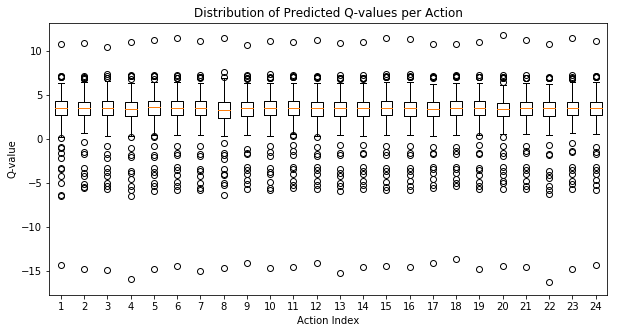

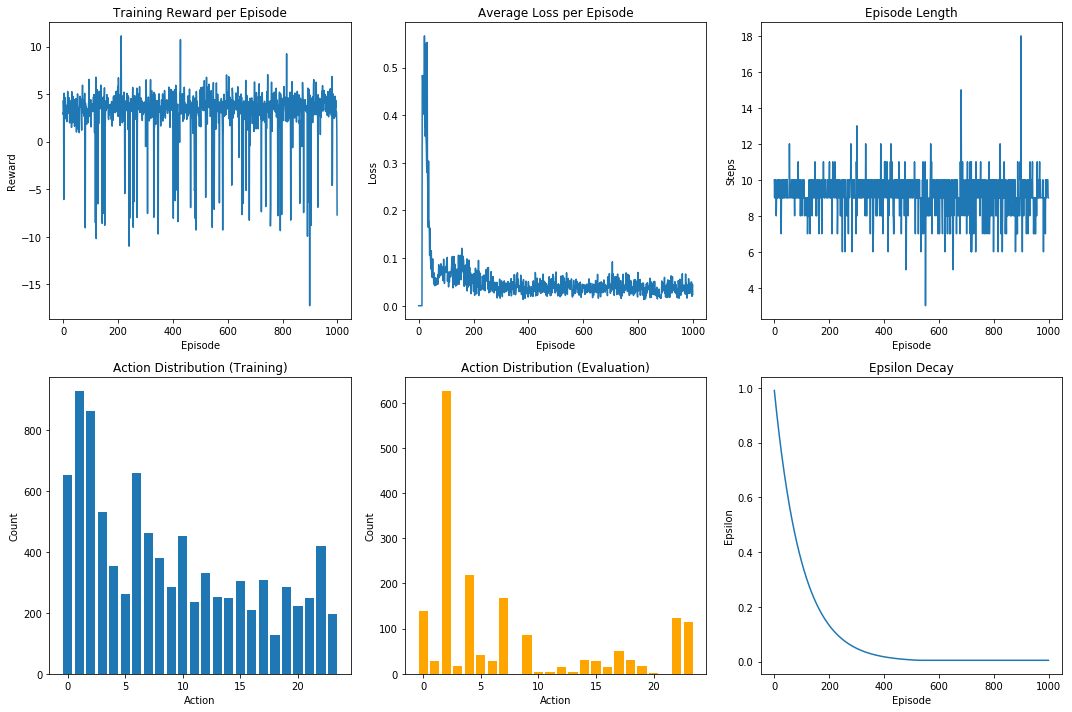

In [115]:
# -------------------------
# Visualizations (optional)
# -------------------------
directory_name = f"plots/{unique_id}"
try:
    os.mkdir(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{directory_name}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

def visualize_q_distribution(model, n_samples=200):
    sampled_states = []
    for _ in range(n_samples):
        reset_output = env.reset()
        s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        sampled_states.append(np.array(s).flatten())
    states_t = torch.FloatTensor(np.vstack(sampled_states)).to(device)
    with torch.no_grad():
        q_vals = model(states_t).cpu().numpy()
    plt.figure(figsize=(10,5))
    plt.boxplot(q_vals)
    plt.title("Distribution of Predicted Q-values per Action")
    plt.xlabel("Action Index")
    plt.ylabel("Q-value")
    plt.savefig(f"plots/{unique_id}/q_values.png")
    plt.show()
    plt.close()

visualize_q_distribution(policy_net)

plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.plot(reward_history)
plt.title("Training Reward per Episode")
plt.xlabel("Episode"); plt.ylabel("Reward")

plt.subplot(2,3,2)
plt.plot(loss_history)
plt.title("Average Loss per Episode")
plt.xlabel("Episode"); plt.ylabel("Loss")

plt.subplot(2,3,3)
plt.plot(episode_length)
plt.title("Episode Length")
plt.xlabel("Episode"); plt.ylabel("Steps")

plt.subplot(2,3,4)
plt.bar(np.arange(action_size), action_counts)
plt.title("Action Distribution (Training)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,5)
plt.bar(np.arange(action_size), eval_actions, color='orange')
plt.title("Action Distribution (Evaluation)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,6)
plt.plot(epsilon_history)
plt.title("Epsilon Decay")
plt.xlabel("Episode"); plt.ylabel("Epsilon")

plt.tight_layout()
plt.savefig(f"plots/{unique_id}/training_plots.png")
plt.show()
plt.close()


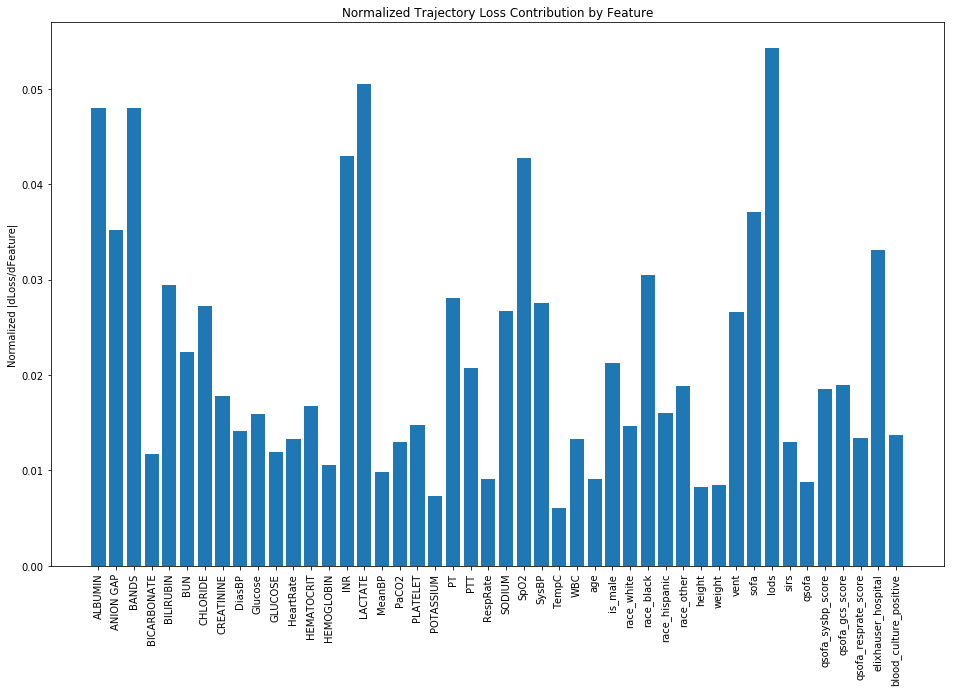

In [116]:
# -------------------------
# Feature gradient importance (optional)
# -------------------------
def compute_feature_loss_importance(model, memory, batch_size=256):
    if len(memory) < batch_size:
        print("Not enough samples in memory.")
        return None, None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    states.requires_grad = True

    q_values = policy_net(states).gather(1, actions)
    next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
    next_q_values = target_net(next_states).gather(1, next_actions).detach()
    target_q = rewards + (gamma * next_q_values * (1 - dones))

    loss = (q_values - target_q).pow(2).mean()
    loss.backward(retain_graph=True)

    grad_magnitudes = states.grad.abs().mean(dim=0).cpu().numpy()
    norm_grad = grad_magnitudes / (grad_magnitudes.sum() + 1e-8)

    feature_idx = np.arange(len(norm_grad))
    plt.figure(figsize=(16,10))
    feature_names = env.feature_names if hasattr(env, 'feature_names') else ["f{}".format(i) for i in range(state_size)]
    plt.bar(feature_names[0:46], norm_grad)
    plt.xticks(rotation=90)
    plt.title("Normalized Trajectory Loss Contribution by Feature")
    plt.ylabel("Normalized |dLoss/dFeature|")
    plt.savefig(f"plots/{unique_id}/loss_by_feature.png")
    plt.show()
    plt.close()

    return grad_magnitudes, norm_grad

# Run after training:
grad_mags, norm_grad = compute_feature_loss_importance(policy_net, memory)


Directory 'trees/1761691427' created successfully.
Distillation complete - Tree fidelity to policy: 35.83%


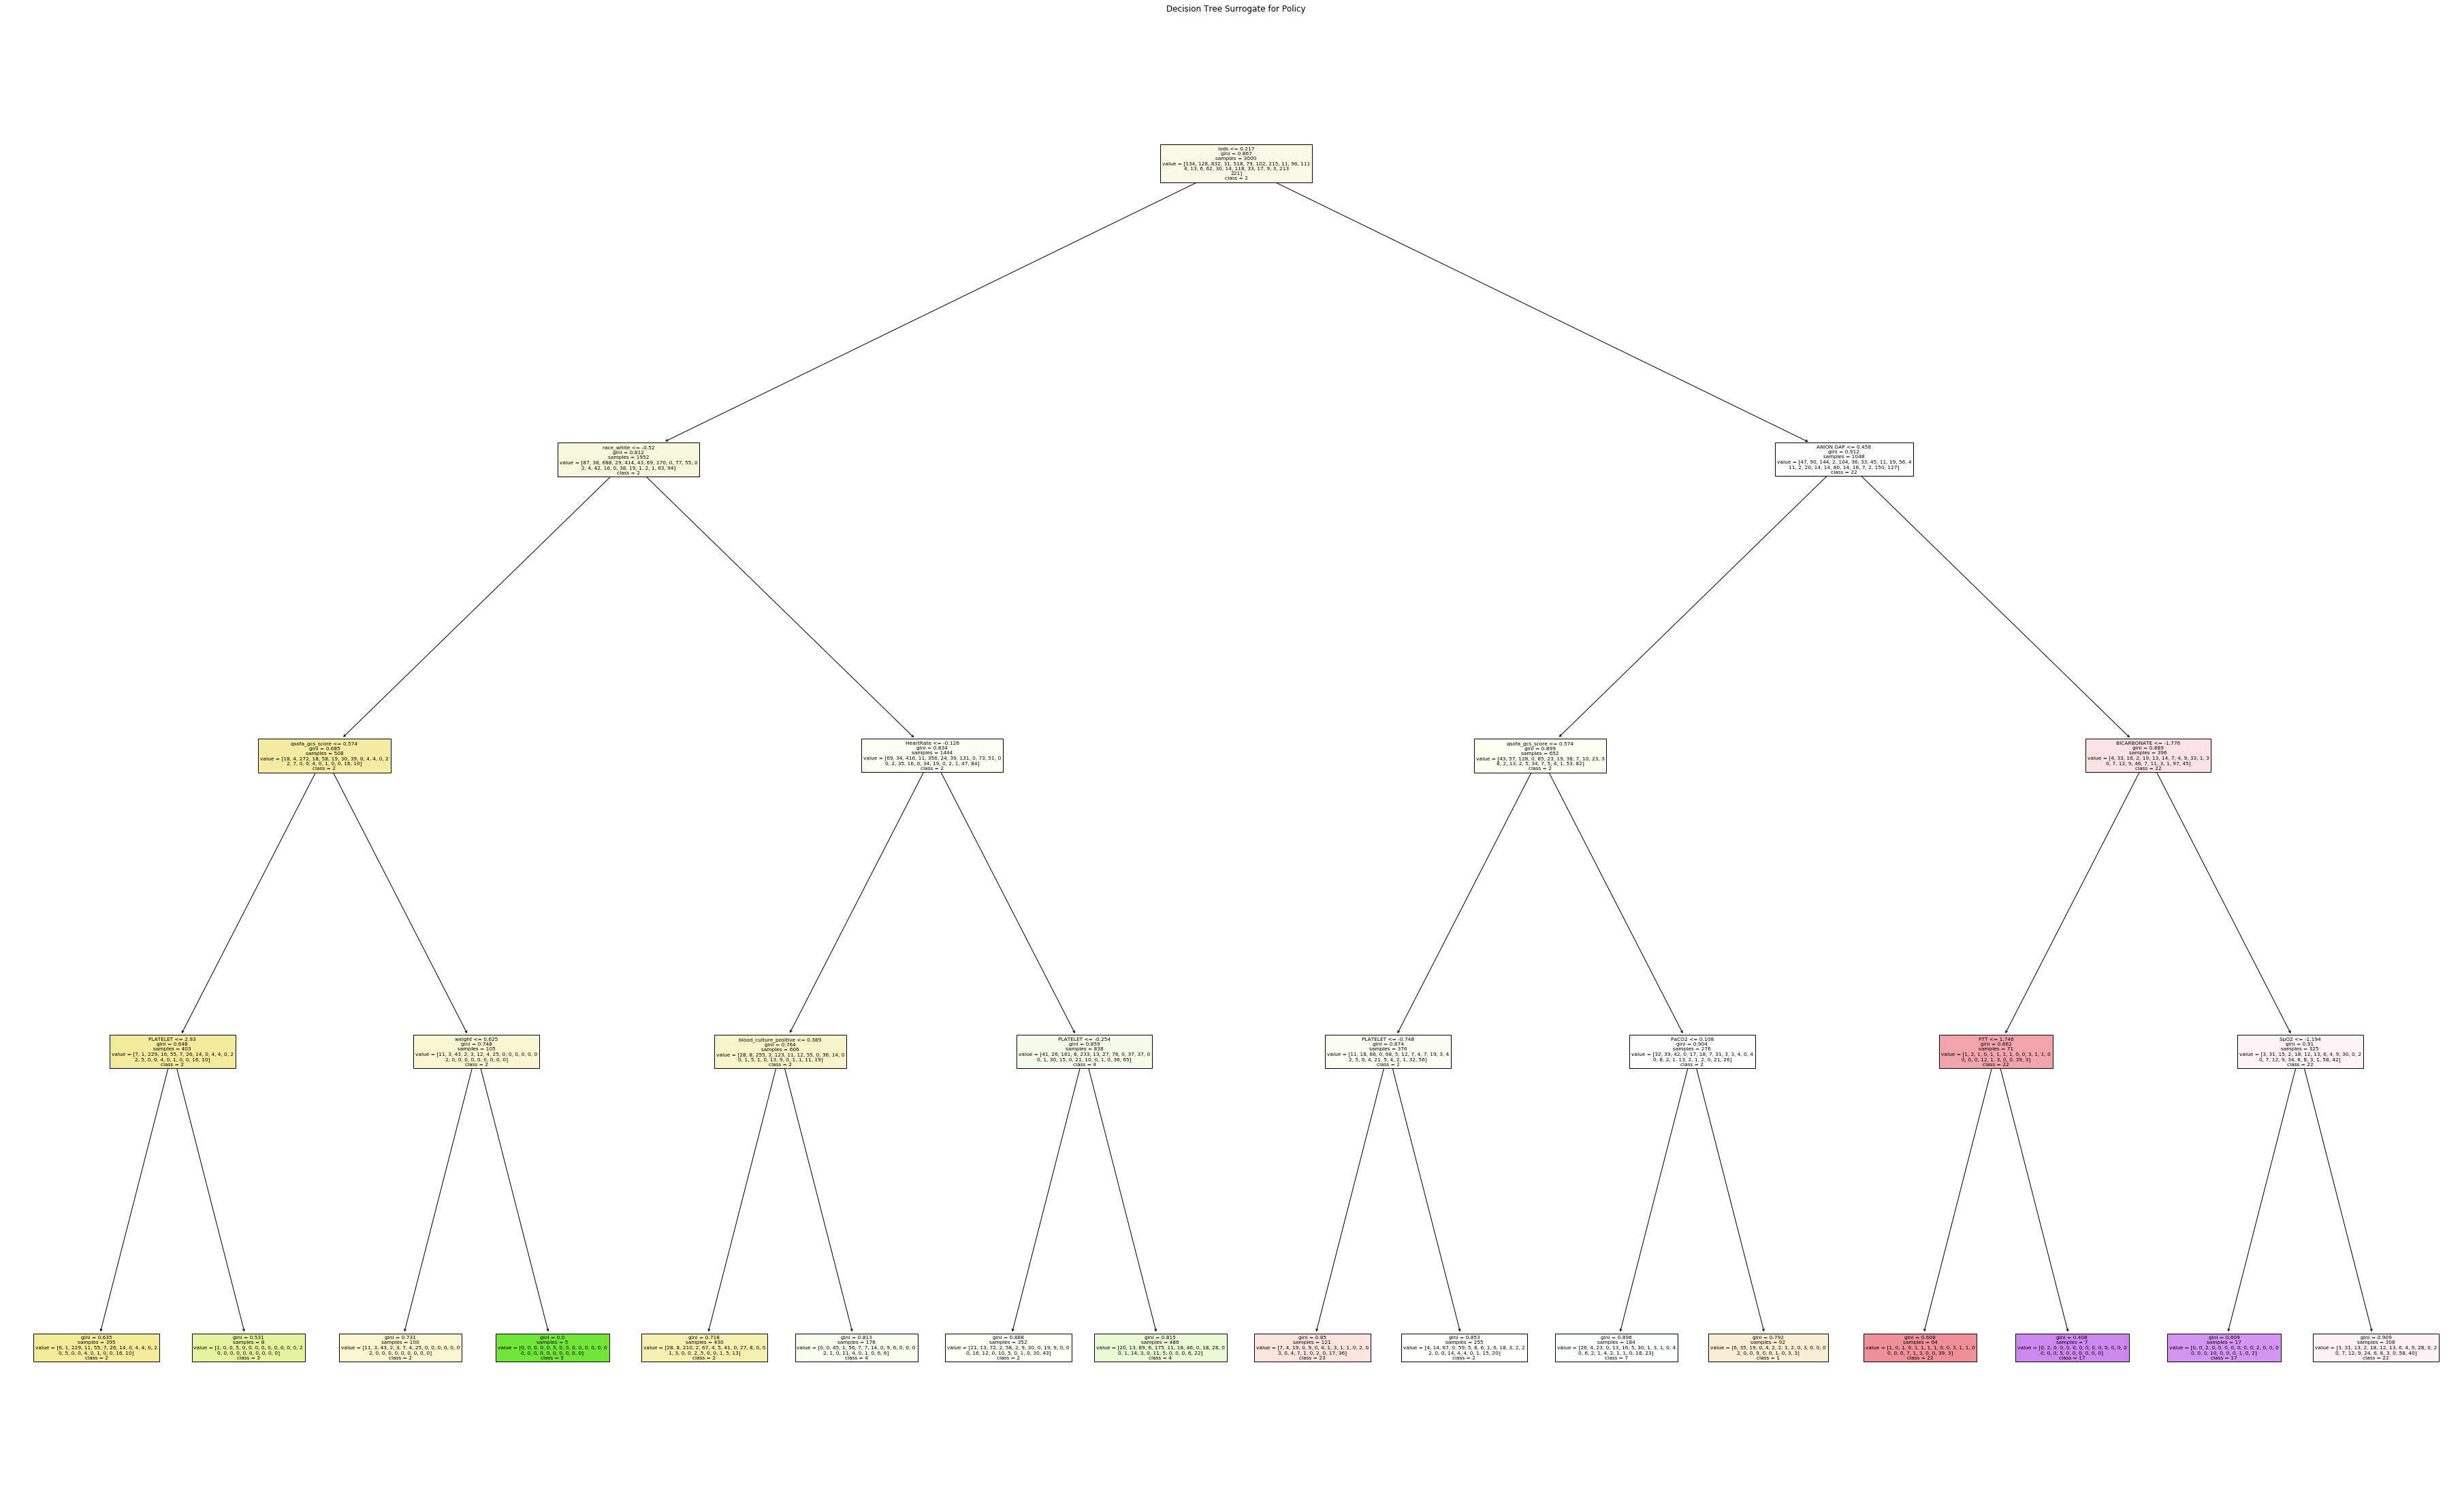

|--- lods <= 0.22
|   |--- race_white <= -0.52
|   |   |--- qsofa_gcs_score <= 0.57
|   |   |   |--- PLATELET <= 2.93
|   |   |   |   |--- class: 2
|   |   |   |--- PLATELET >  2.93
|   |   |   |   |--- class: 3
|   |   |--- qsofa_gcs_score >  0.57
|   |   |   |--- weight <= 0.63
|   |   |   |   |--- class: 2
|   |   |   |--- weight >  0.63
|   |   |   |   |--- class: 5
|   |--- race_white >  -0.52
|   |   |--- HeartRate <= -0.13
|   |   |   |--- blood_culture_positive <= 0.39
|   |   |   |   |--- class: 2
|   |   |   |--- blood_culture_positive >  0.39
|   |   |   |   |--- class: 4
|   |   |--- HeartRate >  -0.13
|   |   |   |--- PLATELET <= -0.25
|   |   |   |   |--- class: 2
|   |   |   |--- PLATELET >  -0.25
|   |   |   |   |--- class: 4
|--- lods >  0.22
|   |--- ANION GAP <= 0.46
|   |   |--- qsofa_gcs_score <= 0.57
|   |   |   |--- PLATELET <= -0.75
|   |   |   |   |--- class: 23
|   |   |   |--- PLATELET >  -0.75
|   |   |   |   |--- class: 2
|   |   |--- qsofa_gcs_score >  0.5

In [117]:
# -------------------------
# === XRL MODULE 1: Policy Distillation -> Decision Tree
# -------------------------
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score

directory_name = f"trees/{unique_id}"
try:
    os.mkdir(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{directory_name}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

def distill_policy_to_tree(model, env, n_samples=3000, max_depth=4):
    model.eval()
    X, y = [], []

    for _ in range(n_samples):
        reset_output = env.reset()
        s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        s = np.array(s).flatten()
        X.append(s)

        with torch.no_grad():
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q_vals = model(s_t)
            action = torch.argmax(q_vals).item()
            y.append(action)

    X = np.array(X)
    y = np.array(y)

    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree.fit(X, y)

    fidelity = accuracy_score(y, tree.predict(X))
    print("Distillation complete - Tree fidelity to policy: {:.2f}%".format(fidelity * 100))

    with open(f"trees/{unique_id}/tree_fidelity.txt", 'w', encoding='utf-8') as file:
        file.write("Distillation complete - Tree fidelity to policy: {:.2f}%".format(fidelity * 100))

    plt.figure(figsize=(64, 40))
    feature_names = getattr(env, "feature_names", ["f{}".format(i) for i in range(X.shape[1])])
    plot_tree(tree, feature_names=feature_names[0:46],
              class_names=[str(i) for i in range(env.action_space.n)], filled=True)
    plt.title("Decision Tree Surrogate for Policy")
    plt.savefig(f"plots/{unique_id}/decision_tree.png")
    plt.show()
    plt.close()

    print(export_text(tree, feature_names=feature_names[0:46]))
    return tree

policy_tree = distill_policy_to_tree(policy_net, env, n_samples=3000, max_depth=4)

# Save the tree if desired (pickle)
try:
    import pickle
    with open(f"trees/{unique_id}/policy_tree.pkl", "wb") as f:
        pickle.dump(policy_tree, f)
    print("Saved tree as 'policy_tree.pkl'")
except Exception as e:
    print("Could not save tree: {}".format(e))


# -------------------------
# === XRL MODULE 2: SHAP explanations (KernelExplainer for Py3.6)
# -------------------------
import shap

def explain_policy_with_shap(model, env, n_samples=500, background_size=100, explain_samples=200):
    model.eval()

    # Sample states
    states = []
    for _ in range(n_samples):
        reset_output = env.reset()
        s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        states.append(np.array(s).flatten())
    X = np.array(states)

    # Model wrapper for SHAP: returns (N, action_size) array
    def q_predict(x):
        x_t = torch.FloatTensor(x).to(device)
        with torch.no_grad():
            q_vals = model(x_t).cpu().numpy()
        return q_vals

    # KernelExplainer works with old SHAP versions and Py3.6
    if len(X) < background_size:
        background = X
    else:
        idx = np.random.choice(len(X), background_size, replace=False)
        background = X[idx]

    print("Building KernelExplainer (this may take some time)...")
    explainer = shap.KernelExplainer(q_predict, background)
    # Limit explained samples for speed; KernelExplainer is expensive
    to_explain = X[:explain_samples]
    shap_values = explainer.shap_values(to_explain)

    feature_names = getattr(env, "feature_names", ["f{}".format(i) for i in range(X.shape[1])])

    # shap_values is a list (one array per model output), each array shape = (samples, features)
    # We'll show summaries for each action's Q-value
    for a_idx in range(len(shap_values)):
        print("Summary plot for action {}".format(a_idx))
        try:
            shap.summary_plot(shap_values[a_idx], features=to_explain, feature_names=feature_names, show=True)
        except Exception as e:
            print("Could not show SHAP summary_plot for action {}: {}".format(a_idx, e))

    # Return the raw shap_values + the data used
    return {"shap_values": shap_values, "data": to_explain, "feature_names": feature_names}

shap_res = explain_policy_with_shap(policy_net, env, n_samples=500, background_size=100, explain_samples=200)


# -------------------------
# Optional: Shapley Decision Boundary (2D visualization)
# -------------------------
def shapley_decision_boundary(model, shap_res, feature_idx=(0,1), grid_size=50):
    f1, f2 = feature_idx
    data = shap_res["data"]
    feature_names = shap_res["feature_names"]

    f1_range = np.linspace(data[:, f1].min(), data[:, f1].max(), grid_size)
    f2_range = np.linspace(data[:, f2].min(), data[:, f2].max(), grid_size)
    grid = np.array([[a, b] for a in f1_range for b in f2_range])

    base = data.mean(axis=0)
    X_grid = np.tile(base, (grid.shape[0], 1))
    X_grid[:, f1] = grid[:, 0]
    X_grid[:, f2] = grid[:, 1]

    with torch.no_grad():
        q_vals = model(torch.FloatTensor(X_grid).to(device)).cpu().numpy()
    actions = np.argmax(q_vals, axis=1)

    plt.figure(figsize=(8,6))
    plt.tricontourf(grid[:,0], grid[:,1], actions, cmap='Spectral', alpha=0.7)
    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])
    plt.title("Shapley-Informed Policy Decision Regions")
    plt.colorbar(label='Action')
    plt.show()

# Example: use features 0 and 1 (change to most informative ones based on SHAP)
shapley_decision_boundary(policy_net, shap_res, feature_idx=(0,1), grid_size=60)

print("Script finished.")
